<a href="https://colab.research.google.com/github/Joohhnnyyy/Pro/blob/main/Weather_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from datetime import datetime
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer  # Add RobustScaler, PowerTransformer
from sklearn.impute import KNNImputer, SimpleImputer  # Add KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns




# 1. Load Data
file_path = 'final_data1.csv'  # Replace with your actual path
try:
    df = pd.read_csv(file_path, parse_dates=['Date'], dayfirst=True)
    print(f"Successfully loaded data from '{file_path}'.")
except FileNotFoundError:
    print(f"Error: '{file_path}' not found. Please provide the correct file path.")
    exit()
except pd.errors.ParserError:
    print(f"Error: Could not parse CSV file. Check the format.")
    exit()
except Exception as e:
    print(f"An error occurred: {e}")
    exit()

print(df.head())

# 2. Feature Engineering

df['WindDirection_sin'] = np.sin(np.radians(df['Wind Direction at 2 Meters (Degrees)']))
df['WindDirection_cos'] = np.cos(np.radians(df['Wind Direction at 2 Meters (Degrees)']))

# Lagged Features (Extensive and Weighted for Precipitation)
for i in range(1, 31):  # Extend to 30 days
    weight = np.exp(-i / 7)  # Example weighting function (adjust as needed)
    df[f'Precipitation_lag{i}_weighted'] = df['Precipitation Corrected (mm/day)'].shift(i) * weight
for i in range(1, 15):  # Other variables
    for col in ['Temperature at 2 meters (c)', 'Wind Speed at 2 Meters (m/s)', 'WindDirection_sin', 'WindDirection_cos']:
        df[f'{col}_lag{i}'] = df[col].shift(i)



# Rolling Features (Varied for Precipitation)
for window in [3, 7, 14]:
    df[f'Precipitation_rolling{window}_mean'] = df['Precipitation Corrected (mm/day)'].rolling(window=window, center=False).mean()
    df[f'Precipitation_rolling{window}_median'] = df['Precipitation Corrected (mm/day)'].rolling(window=window, center=False).median()
    df[f'Precipitation_rolling{window}_max'] = df['Precipitation Corrected (mm/day)'].rolling(window=window, center=False).max()
for col in ['Temperature at 2 meters (c)', 'Wind Speed at 2 Meters (m/s)']:
    df[f'{col}_rolling7'] = df[col].rolling(window=7, center=False).mean()
    df[f'{col}_rolling7_var'] = df[col].rolling(window=7, center=False).var()

# Add Wind Components
df['Wind_East'] = df['Wind Speed at 2 Meters (m/s)'] * np.sin(np.radians(df['Wind Direction at 2 Meters (Degrees)']))
df['Wind_North'] = df['Wind Speed at 2 Meters (m/s)'] * np.cos(np.radians(df['Wind Direction at 2 Meters (Degrees)']))

# Fourier Analysis (Example for annual cycle)
from numpy.fft import fft # Import fft function from numpy.fft
precipitation_fft = fft(df['Precipitation Corrected (mm/day)'].fillna(0))  # Fill NaN before FFT
frequencies = np.fft.fftfreq(df.shape[0], d=1)  # Assuming daily data

# Identify dominant frequencies (e.g., annual cycle)
dominant_freq_indices = np.where(np.abs(frequencies) < 1/365.25)[0]  # Annual cycle

# Create Fourier features
for freq_index in dominant_freq_indices:
    df[f'Precipitation_fft_sin_{freq_index}'] = np.sin(2 * np.pi * frequencies[freq_index] * df.index)
    df[f'Precipitation_fft_cos_{freq_index}'] = np.cos(2 * np.pi * frequencies[freq_index] * df.index)


# Handle Missing Values (Imputation before dropping NaNs)
imputer = KNNImputer(n_neighbors=5)  # Use KNN Imputer
for col in df.columns:
    df[col] = imputer.fit_transform(df[[col]])

# Yeo-Johnson Transform for Precipitation
pt = PowerTransformer(method='yeo-johnson')
df['Precipitation Corrected (mm/day)'] = pt.fit_transform(df[['Precipitation Corrected (mm/day)']])

df.dropna(inplace=True)  # Drop any remaining NaNs after imputation
df.drop('Date', axis=1, inplace=True)

# 3. Train and Evaluate Models (using TimeSeriesSplit and Pipeline)
models = {}
r2_scores = {}
mse_scores = {}

# Custom scorer for RMSE (Root Mean Squared Error)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

target_variables = ['Temperature at 2 meters (c)', 'Precipitation Corrected (mm/day)', 'Wind Speed at 2 Meters (m/s)']
# Exclude 'Date' or any date-related features from features
features = [col for col in df.columns if col not in target_variables + ['Date']] # Modified line
for target in target_variables:
    X = df[features]
    y = df[target]

    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Pipeline for preprocessing and modeling
    pipeline = Pipeline([
        ('scaler', RobustScaler()),  # Use RobustScaler (less sensitive to outliers)
        ('model', LGBMRegressor(random_state=42))  # Use LightGBM. You can change this to XGBRegressor or RandomForestRegressor
    ])

    # Cross-validation with TimeSeriesSplit
    ts_cv = TimeSeriesSplit(n_splits=5)
    cv_scores = cross_val_score(pipeline, X_train_full, y_train_full, cv=ts_cv, scoring=rmse_scorer)  # Use RMSE
    print(f"{target} CV RMSE: {-cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")  # Note the negative sign because RMSE is a cost function

    # Train on the full training set
    pipeline.fit(X_train_full, y_train_full)
    y_pred_test = pipeline.predict(X_test)

    r2_scores[target] = r2_score(y_test, y_pred_test)
    mse_scores[target] = mean_squared_error(y_test, y_pred_test)
    models[target] = pipeline  # Store the entire pipeline

    print(f"Model performance for {target}:")
    print(f"Mean Squared Error: {mse_scores[target]:.2f}")
    print(f"R-squared: {r2_scores[target]:.2f}")

# 4. Prediction Function (Corrected and Improved)
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor  # Add LightGBM
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from datetime import datetime
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer  # Add RobustScaler, PowerTransformer
from sklearn.impute import KNNImputer, SimpleImputer  # Add KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline  # Add Pipeline
import matplotlib.pyplot as plt
import seaborn as sns


# 4. Prediction Function (Corrected and Improved)
def predict_weather(date_str, models, features, df):  # Added df as argument
    try:
        input_date = datetime.strptime(date_str, '%d/%m/%Y')
    except ValueError:
        return "Invalid date format. Please use DD/MM/YYYY."

    input_data = pd.DataFrame({
        'Year': [input_date.year], 'Month': [input_date.month], 'Day': [input_date.day],
        'DayOfYear': [input_date.timetuple().tm_yday], 'WeekOfYear': [input_date.isocalendar().week]
    })

    input_data['DayOfYear_sin'] = np.sin(2 * np.pi * input_data['DayOfYear'] / 365.25)
    input_data['DayOfYear_cos'] = np.cos(2 * np.pi * input_data['DayOfYear'] / 365.25)
    input_data['WeekOfYear_sin'] = np.sin(2 * np.pi * input_data['WeekOfYear'] / 52)
    input_data['WeekOfYear_cos'] = np.cos(2 * np.pi * input_data['WeekOfYear'] / 52)

    # Assuming 'Wind Direction at 2 Meters (Degrees)' is a feature used in your model:
    input_data['Wind Direction at 2 Meters (Degrees)'] = df['Wind Direction at 2 Meters (Degrees)'].mean()  # Use the average wind direction from the training data
    input_data['WindDirection_sin'] = np.sin(np.radians(input_data['Wind Direction at 2 Meters (Degrees)']))
    input_data['WindDirection_cos'] = np.cos(np.radians(input_data['Wind Direction at 2 Meters (Degrees)']))

    # Impute using the mean of the original dataframe 'df'
    for col in features:
        if f'{col}_lag1' in df.columns:  # Check if it's a lagged feature
            for i in range(1, 15):
                input_data[f'{col}_lag{i}'] = df[col].mean()
        elif col in df.columns and col not in input_data.columns:  # Add this condition to avoid overwriting existing columns
            input_data[col] = df[col].mean()


    # Ensure all features are present in input_data (handle missing features)
    missing_features = [f for f in features if f not in input_data.columns]
    for f in missing_features:
        input_data[f] = 0  # Fill missing features with 0 (or another appropriate value)

    input_data = input_data[features]  # Important: Select only the used features and respect order

    predictions = {}
    for target in target_variables:
        pipeline = models[target]  # Get the entire pipeline
        try:
            predictions[target] = pipeline.predict(input_data)[0]  # Predict using the pipeline
        except Exception as e:
            print(f"Error predicting {target}: {e}")
            predictions[target] = np.nan  # Or handle the error in another way

    return predictions

# Run Prediction and print results together
date_input = input("Enter date (DD/MM/YYYY): ")
predictions = predict_weather(date_input, models, features, df)  # Pass the required arguments: models, features, and df

if isinstance(predictions, dict):
    for target in target_variables:
        print(f"For {target}:")
        print(f"  Predicted Value: {predictions[target]:.2f}")
        print(f"  R-squared (on test set): {r2_scores.get(target, np.nan):.2f}")
        print(f"  Mean Squared Error (on test set): {mse_scores.get(target, np.nan):.2f}")
else:
    print(predictions)

predictions = predict_weather(date_input, models, features, df) # Pass the required arguments: models, features, and df

Successfully loaded data from 'final_data1.csv'.
        Date  Temperature at 2 meters (c)  Precipitation Corrected (mm/day)  \
0 2001-01-01                        13.23                              14.9   
1 2001-01-02                        12.75                               0.0   
2 2001-01-03                        13.02                               0.0   
3 2001-01-04                        12.54                               0.0   
4 2001-01-05                        11.97                               0.0   

   Specific Humidity at 2 Meters (g/kg)  Wind Direction at 2 Meters (Degrees)  \
0                                  8.09                                 101.3   
1                                  5.85                                 348.9   
2                                  5.75                                 310.1   
3                                  4.90                                 310.1   
4                                  3.88                                

<ipython-input-22-02882ce9c620>:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_rolling7_var'] = df[col].rolling(window=7, center=False).var()
<ipython-input-22-02882ce9c620>:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_rolling7'] = df[col].rolling(window=7, center=False).mean()
<ipython-input-22-02882ce9c620>:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 48572
[LightGBM] [Info] Number of data points in the train set: 1173, number of used features: 202
[LightGBM] [Info] Start training from score 24.731364


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006955 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51298
[LightGBM] [Info] Number of data points in the train set: 2341, number of used features: 202
[LightGBM] [Info] Start training from score 24.929158


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Model performance for Wind Speed at 2 Meters (m/s):
Mean Squared Error: 0.00
R-squared: 0.99
Enter date (DD/MM/YYYY): 30/03/2025


<ipython-input-22-02882ce9c620>:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_data[col] = df[col].mean()
<ipython-input-22-02882ce9c620>:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_data[col] = df[col].mean()
<ipython-input-22-02882ce9c620>:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fr

For Temperature at 2 meters (c):
  Predicted Value: 25.15
  R-squared (on test set): 0.99
  Mean Squared Error (on test set): 0.81
For Precipitation Corrected (mm/day):
  Predicted Value: 0.45
  R-squared (on test set): 0.94
  Mean Squared Error (on test set): 0.06
For Wind Speed at 2 Meters (m/s):
  Predicted Value: 0.76
  R-squared (on test set): 0.99
  Mean Squared Error (on test set): 0.00


<ipython-input-22-02882ce9c620>:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_data[col] = df[col].mean()
<ipython-input-22-02882ce9c620>:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_data[col] = df[col].mean()
<ipython-input-22-02882ce9c620>:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fr

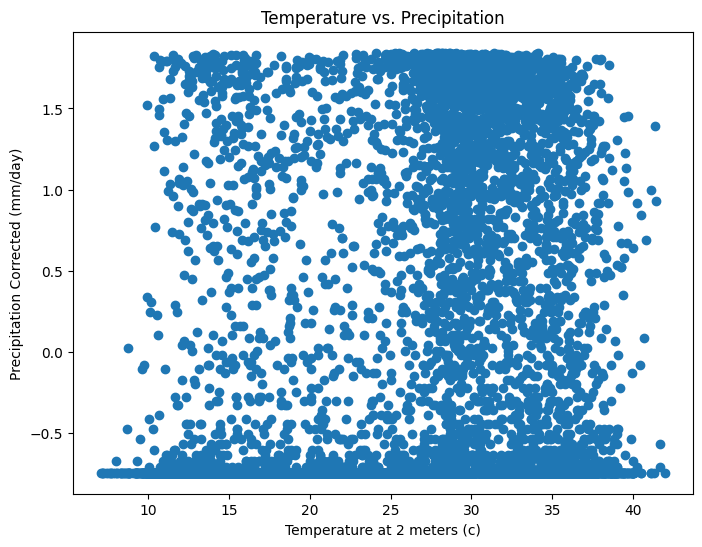

In [29]:

import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(8, 6))
plt.scatter(df['Temperature at 2 meters (c)'], df['Precipitation Corrected (mm/day)'])
plt.xlabel('Temperature at 2 meters (c)')
plt.ylabel('Precipitation Corrected (mm/day)')
plt.title('Temperature vs. Precipitation')
plt.show()






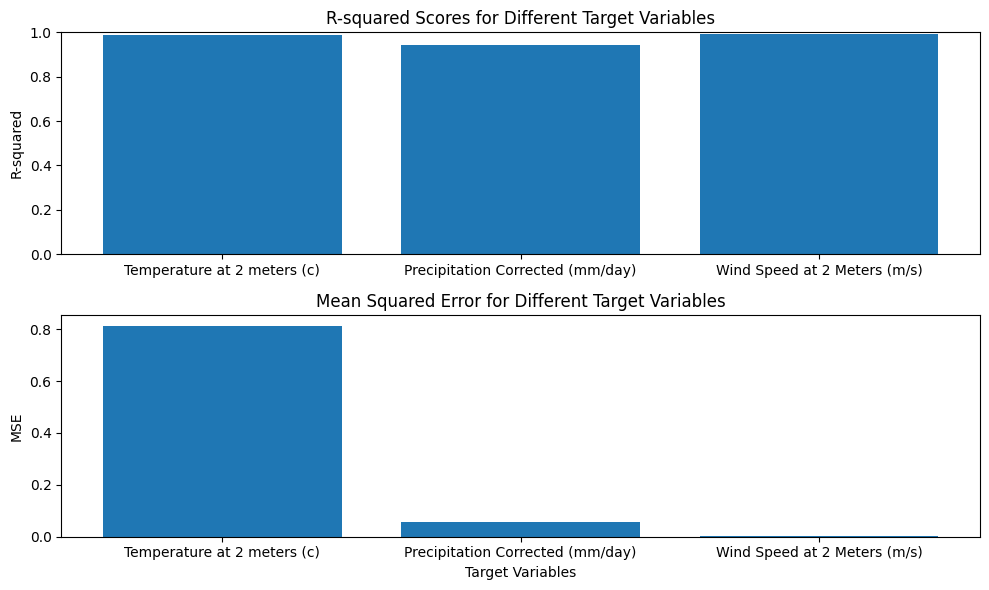

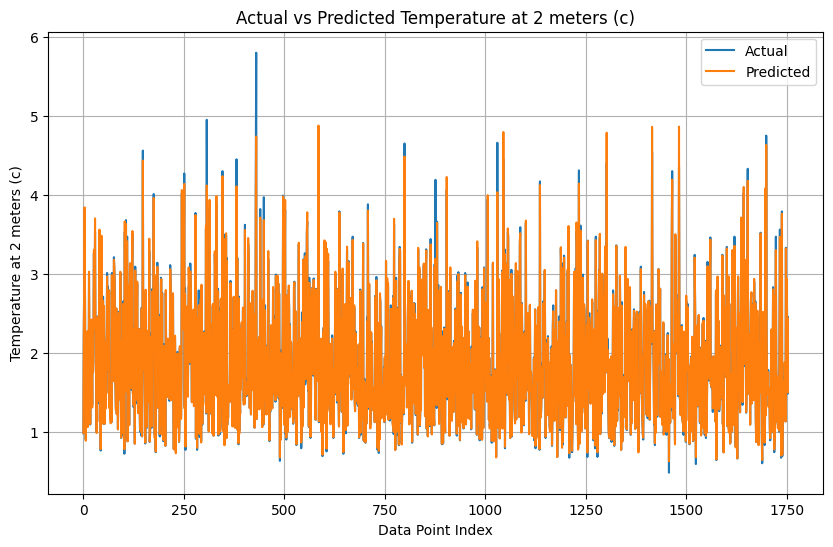

In [23]:

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.bar(r2_scores.keys(), r2_scores.values())
plt.title('R-squared Scores for Different Target Variables')
plt.ylabel('R-squared')
plt.ylim(0,1)

plt.subplot(2, 1, 2)
plt.bar(mse_scores.keys(), mse_scores.values())
plt.title('Mean Squared Error for Different Target Variables')
plt.ylabel('MSE')
plt.xlabel('Target Variables')
plt.tight_layout()
plt.show()


target_to_plot = 'Temperature at 2 meters (c)'

plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_test, label='Predicted')
plt.title(f'Actual vs Predicted {target_to_plot}')
plt.xlabel('Data Point Index')
plt.ylabel(target_to_plot)
plt.legend()
plt.grid(True)
plt.show()
